#GoogleDrive Connect

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Notebook Overview**
1. Load raw data.  
2. Clean and align the target for horizon=1.  
3. Split once into outer train/test = 80/20. 2012

4. Run walk-forward validation only on the outer-train set for Bayesian tuning. 2012 *0.9 = 1811/

5. fEATURE ENG
6. SCALE
5. Aggregate fold RMSE inside one Bayesian objective value.  
6. Select the best hyperparameters from the best aggregate RMSE score.  
7. Refit preprocessing on the full outer-train set.
8. Train final models across multiple random seeds.
9. Optionally use the last 10% of outer-train as a time-based internal validation split.811
10. Evaluate once on the untouched outer-test set.
Why there are many pbounds:  hyperparameter spaces.
- They are hyperparameter spaces borrowed from different studies so you can compare which spaces.
  search range works best with the same cleaned pipeline.  

Why there are many model builders:  architectures.
- They represent alternative CNN/BiLSTM-style architectures inspired by different studies  model definitions.
  so you can compare which architecture works best under the same tuning/evaluation logic.

Why there is no final-model walk-forward function anymore:
- In the finalized pipeline, walk-forward is used only for tuning on the outer-train set.
- The final model is retrained on the full outer-train set and evaluated once on outer-test.


# Install and Import
Install required packages and import all libraries used in the pipeline.

In [3]:
!pip install numpy pandas scikit-learn matplotlib bayesian-optimization tensorflow

In [4]:
from __future__ import annotations  # Enable postponed evaluation of annotations.

import copy  # Copy nested dictionaries safely.
import math  # Use math helpers for stable calculations.
import os  # Read environment variables and filesystem paths.
import random  # Control Python-level randomness.
from dataclasses import dataclass  # Store configuration cleanly.
from typing import Callable  # Type hint for callable signatures.
from typing import Dict  # Type hint for dictionaries.
from typing import List  # Type hint for lists.
from typing import Optional  # Type hint for optional values.
from typing import Tuple  # Type hint for tuple return types.

import matplotlib.pyplot as plt  # Plot training curves and predictions.
import numpy as np  # Numerical array operations.
import pandas as pd  # Tabular data handling.
import pywt  # Wavelet denoising support.
import tensorflow as tf  # Deep learning framework.
from bayes_opt import BayesianOptimization  # Bayesian hyperparameter optimization.
from sklearn.metrics import mean_absolute_error  # MAE evaluation metric.
from sklearn.metrics import mean_squared_error  # MSE and RMSE evaluation metric.
from sklearn.metrics import r2_score  # R² evaluation metric.
from sklearn.preprocessing import MinMaxScaler  # Feature and target scaling.
from tensorflow.keras.callbacks import EarlyStopping  # Early stopping during training.
from tensorflow.keras.layers import Activation  # Optional activation layer for some models.
from tensorflow.keras.layers import BatchNormalization  # Optional batch normalization layer.
from tensorflow.keras.layers import Bidirectional  # Bidirectional LSTM wrapper.
from tensorflow.keras.layers import Conv1D  # 1D convolution layer.
from tensorflow.keras.layers import Dense  # Dense output and hidden layers.
from tensorflow.keras.layers import Dropout  # Dropout regularization layer.
from tensorflow.keras.layers import Flatten  # Optional flatten layer for some architectures.
from tensorflow.keras.layers import Input  # Explicit input layer.
from tensorflow.keras.layers import LSTM  # LSTM recurrent layer.
from tensorflow.keras.layers import MaxPooling1D  # 1D max pooling layer.
from tensorflow.keras.models import Sequential  # Sequential Keras model builder.
from tensorflow.keras.optimizers import Adam  # Adam optimizer.

# **GLOBAL CONFIGURATION**   

##Initial Configuration

In [5]:
TARGET_COL = "Gold_Futures"  # Define the target column once.
HORIZON = 1  # Predict one day ahead.
OUTER_TEST_SIZE = 0.20  # Reserve 20% of the full dataset as untouched outer test.
FINAL_INTERNAL_VAL_RATIO = 0.10  # Reserve the last 10% of outer-train for final-model val_loss.
N_WALK_FORWARD_FOLDS = 5  # Use five sequential folds during tuning.
BAYES_INIT_POINTS = 5  # Number of random warm-up Bayesian trials.
BAYES_N_ITER = 10  # Number of guided Bayesian trials after warm-up.
FINAL_SEEDS = [0, 1, 2, 42, 99, 123]  # Multi-seed robustness list copied from the cited study.
GLOBAL_TUNING_SEED = 42  # Fixed seed for reproducible tuning.
USE_DENOISING = False  # Toggle denoising branch if you want to test it later.
DENOISE_WAVELET = "coif3"  # Default wavelet family.
DENOISE_LEVEL = 1  # Default denoising level.
DENOISE_MODE = "soft"  # Default wavelet thresholding mode.
DEFAULT_EPOCHS = 50  # Default training epochs for both tuning and final runs.
DEFAULT_PATIENCE = 10  # Default early stopping patience.
LAG_FEATURES = [1, 2, 3, 5, 10]  # Lag windows for causal feature engineering.
ROLLING_WINDOWS = [3, 5, 10]  # Rolling windows for causal mean/std feature engineering.

## Dataset file paths

In [6]:
DATASET_PATHS = {
    "RRL": "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/gold_RRL.csv",  # Original RRL CSV path.
    "TRUE": "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/gold_TRUE.csv",  # Original TRUE CSV path.
    "MIX": "/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/gold_MIX.csv",  # Original MIX CSV path.
}

In [7]:
df = pd.read_csv(DATASET_PATHS["RRL"], index_col=0)

In [8]:
df=df.dropna()

## Feature groups

In [9]:
FEATURE_LIBRARY = {
    "RRL": [  # RRL feature list.
        "Silver_Futures",  # Precious-metals co-movement feature.
        "Crude_Oil_Futures",  # Commodity linkage feature.
        "UST10Y_Treasury_Yield",  # Long-rate feature.
        "Federal_Funds_Rate",  # Policy-rate feature.
        "Employment_Pop_Ratio",  # Labor-market feature.
        "gepu",  # Policy uncertainty feature.
        "gpr_daily",  # Geopolitical-risk feature.
    ],
    "TRUE": [  # TRUE feature list.
        "Silver_Futures",  # Precious-metals co-movement feature.
        "Real_Effective_Exchange_Rate",  # Dollar-strength feature.
        "Crude_Oil_Futures",  # Commodity linkage feature.
        "UST10Y_Treasury_Yield",  # Long-rate feature.
        "Federal_Funds_Rate",  # Policy-rate feature.
        "gepu",  # Policy uncertainty feature.
        "gpr_daily",  # Geopolitical-risk feature.
    ],
    "MIX": [  # MIX feature list.
        "Silver_Futures",  # Shared feature.
        "Real_Effective_Exchange_Rate",  # TRUE-only feature.
        "Crude_Oil_Futures",  # Shared feature.
        "UST10Y_Treasury_Yield",  # Shared feature.
        "Federal_Funds_Rate",  # Shared feature.
        "Employment_Pop_Ratio",  # RRL-only feature.
        "gepu",  # Shared feature.
        "gpr_daily",  # Shared feature.
    ],
}

# HYPERPARAMETER SPACE LIBRARY

In [10]:
PBOUNDS_LIBRARY = {
    "amini_2024": {  # Hyperparameter space inspired by Amini et al.
        "lookback": (1, 40),  # Lookback search interval.
        "filters": (4, 128),  # Conv1D filter count interval.
        "lstm_units": (10, 50),  # LSTM unit interval.
        "kernel_size": (1, 4),  # Conv1D kernel-size interval.
        "learning_rate": (0.00005, 0.05),  # Learning-rate interval.
        "dropout_rate": (0.10, 0.90),  # Dropout interval.
        "batch_size": (3, 10),  # Batch-size exponent interval; actual batch size = 2 ** exponent.
    },
    "song_2025_compact": {  # Hyperparameter space inspired by one Song-style configuration.
        "lookback": (4, 12),  # Lookback interval.
        "filters": (16, 128),  # Filter interval.
        "lstm_units": (32, 256),  # LSTM-unit interval.
        "kernel_size": (2, 4),  # Kernel interval.
        "learning_rate": (0.0001, 0.01),  # Learning-rate interval corrected to numeric space.
        "dropout_rate": (0.10, 0.50),  # Dropout interval.
        "batch_size": (5, 6),  # Batch-size exponent interval; 32 or 64.
    },
    "duan_2025": {  # Hyperparameter space inspired by Duan et al.
        "lookback": (5, 60),  # Lookback interval.
        "filters": (8, 512),  # Filter interval.
        "lstm_units": (10, 150),  # LSTM-unit interval.
        "kernel_size": (1, 3),  # Kernel interval.
        "learning_rate": (0.0001, 0.01),  # Learning-rate interval normalized to practical values.
        "dropout_rate": (0.10, 0.50),  # Dropout interval.
        "batch_size": (3, 9),  # Batch-size exponent interval.
    },
    "su_2025": {  # Hyperparameter space inspired by Su et al.
        "lookback": (4, 12),  # Lookback interval.
        "filters": (16, 128),  # Filter interval.
        "lstm_units": (32, 128),  # LSTM-unit interval.
        "kernel_size": (3, 7),  # Kernel interval.
        "learning_rate": (1e-5, 1e-2),  # Learning-rate interval.
        "dropout_rate": (0.10, 0.50),  # Dropout interval.
        "batch_size": (4, 6),  # Batch-size exponent interval.
    },
    "tamene_2025": {  # Hyperparameter space inspired by Tamene.
        "lookback": (16, 40),  # Lookback interval.
        "filters": (32, 256),  # Filter interval.
        "kernel_size": (3, 9),  # Kernel interval.
        "lstm_units": (50, 200),  # LSTM-unit interval.
        "dropout_rate": (0.10, 0.50),  # Dropout interval.
        "learning_rate": (1e-4, 1e-2),  # Learning-rate interval.
        "batch_size": (4, 7),  # Batch-size exponent interval.
    },
    "song_2025_wide": {  # Hyperparameter space inspired by another Song-style range.
        "lookback": (16, 60),  # Lookback interval.
        "filters": (16, 128),  # Filter interval.
        "lstm_units": (32, 128),  # LSTM-unit interval.
        "kernel_size": (3, 7),  # Kernel interval.
        "learning_rate": (1e-4, 1e-2),  # Learning-rate interval.
        "dropout_rate": (1e-5, 1e-1),  # Dropout interval.
        "batch_size": (4, 6),  # Batch-size exponent interval.
    },
    "PBOUNDS_RECOMMENDED": {
    "lookback": (12, 40),          # integer
    "filters": (16, 96),           # cast to nearest multiple of 16
    "kernel_size": (2, 5),         # map to {2, 3, 5}
    "lstm_units": (24, 96),        # cast to nearest multiple of 16
    "dropout_rate": (0.10, 0.35),  # continuous
    "learning_rate": (1e-4, 3e-3), # log-scale sampling preferred
    "batch_size": (4, 6),          # exponent -> {16, 32, 64}
    },
    "pbounds_1cnn_1bilstm" : {
    "lookback": (10, 30),
    "filters": (16, 64),
    "kernel_size": (2, 5),
    "lstm_units": (16, 64),
    "dropout_rate": (0.10, 0.30),
    "learning_rate": (1e-4, 3e-3),
    "batch_size": (4, 6),   # 16, 32, 64
    },
    "pbounds_2cnn_1bilstm" : {
    "lookback": (12, 36),
    "filters": (16, 96),
    "kernel_size": (2, 5),
    "lstm_units": (24, 80),
    "dropout_rate": (0.10, 0.35),
    "learning_rate": (1e-4, 3e-3),
    "batch_size": (4, 6),   # 16, 32, 64
},
    "pbounds_from80" : {
    "lookback": (14, 60),
    "filters": (32, 128),
    "lstm_units": (32, 128),
    "kernel_size": (2, 5),
     "learning_rate": (0.0001, 0.001),
    "dropout_rate": (0.2, 0.5),
    "batch_size": (4, 7),
}
}

# CONFIGURATION DATACLASSES  

In [11]:
@dataclass  # Use a dataclass for one experiment definition.
class ExperimentConfig:  # Store user-selectable experiment settings.
    dataset_key: str = "MIX"  # Choose one of: RRL, TRUE, MIX.
    architecture_key: str = "zhang_2023"  # Choose one architecture from the architecture library.
    pbounds_key: str = "su_2025"  # Choose one pbounds entry from the library.
    target_col: str = TARGET_COL  # Store the target column name.
    use_denoising: bool = USE_DENOISING  # Whether to activate the denoising branch.
    outer_test_size: float = OUTER_TEST_SIZE  # Outer hold-out test ratio.
    final_internal_val_ratio: float = FINAL_INTERNAL_VAL_RATIO  # Tail validation ratio for final training.
    n_walk_forward_folds: int = N_WALK_FORWARD_FOLDS  # Number of walk-forward folds.
    bayes_init_points: int = BAYES_INIT_POINTS  # Bayesian warm-up trials.
    bayes_n_iter: int = BAYES_N_ITER  # Bayesian guided trials.
    tuning_seed: int = GLOBAL_TUNING_SEED  # Fixed seed for tuning reproducibility.
    final_seeds: List[int] = None  # Final robustness-seed list.
    denoise_wavelet: str = DENOISE_WAVELET  # Wavelet choice.
    denoise_level: int = DENOISE_LEVEL  # Wavelet level.
    denoise_mode: str = DENOISE_MODE  # Wavelet threshold mode.
    epochs: int = DEFAULT_EPOCHS  # Number of training epochs.
    patience: int = DEFAULT_PATIENCE  # Early stopping patience.

    def __post_init__(self) -> None:  # Normalize mutable defaults after init.
        if self.final_seeds is None:  # Guard against shared mutable defaults.
            self.final_seeds = FINAL_SEEDS[:]  # Copy the default seed list.

# RANDOMNESS CONTROL

In [12]:
def set_global_seed(seed: int) -> None:  # Define one helper to control all supported random generators.
    os.environ["PYTHONHASHSEED"] = str(seed)  # Make Python hash operations more repeatable.
    random.seed(seed)  # Fix Python's random module.
    np.random.seed(seed)  # Fix NumPy randomness.
    tf.keras.utils.set_random_seed(seed)  # Fix TensorFlow and Keras randomness.
    try:  # Try deterministic TensorFlow ops when available.
        tf.config.experimental.enable_op_determinism()  # Ask TensorFlow to prefer deterministic kernels.
    except Exception:  # Ignore if the TensorFlow build does not support it.
        pass  # Do nothing if deterministic ops are unavailable.

# DATA LOADING AND CLEANING

In [13]:
def load_dataset_from_csv(path: str) -> pd.DataFrame:  # Load one CSV dataset from disk.
    df = pd.read_csv(path, index_col=0)  # Read the CSV while preserving the first column as index.
    if not isinstance(df.index, pd.DatetimeIndex):  # Convert the index to a DatetimeIndex if needed.
        df.index = pd.to_datetime(df.index, errors="coerce")  # Parse the index as datetimes.
    df = df.sort_index()  # Sort chronologically to preserve time order.
    df = df.loc[~df.index.isna()].copy()  # Drop rows with invalid datetime index values.
    return df  # Return the loaded dataframe.

def clean_and_align_target(df: pd.DataFrame, target_col: str, horizon: int = 1) -> pd.DataFrame:  # Clean the raw dataframe.
    if target_col not in df.columns:  # Validate the target column before processing.
        raise ValueError(f"Target column '{target_col}' is not present in the dataframe.")  # Fail early if target is missing.
    df = df.copy()  # Work on a copy to avoid side effects.
    df = df.sort_index()  # Preserve chronological order.
    df = df.replace([np.inf, -np.inf], np.nan)  # Replace infinities with NaN before dropping.
    df = df.dropna(axis=0, how="any")  # Drop rows with missing values for stable modeling.
    if horizon != 1:  # Allow future expansion if you later want horizon > 1.
        df["__target_future__"] = df[target_col].shift(-horizon + 1)  # Shift the target to align with the desired horizon.
        df = df.dropna(axis=0, how="any")  # Drop tail rows made invalid by shifting.
        df[target_col] = df["__target_future__"]  # Replace the target with the shifted target.
        df = df.drop(columns=["__target_future__"])  # Remove the temporary helper column.
    return df  # Return the cleaned and aligned dataframe.

def outer_train_test_split(df: pd.DataFrame, test_size: float) -> Tuple[pd.DataFrame, pd.DataFrame]:  # Split the full data once into train/test.
    split_index = int(len(df) * (1.0 - test_size))  # Compute the chronological split point.
    df_train_outer = df.iloc[:split_index].copy()  # Keep the earliest block as outer train.
    df_test = df.iloc[split_index:].copy()  # Keep the latest block as untouched outer test.
    return df_train_outer, df_test  # Return both outer splits.

# FEATURE ENGINEERING

In [14]:
def engineer_features_causally(  # Build lag and rolling features without future leakage.
    train_df: pd.DataFrame,  # Historical block used for fitting or context.
    future_df: Optional[pd.DataFrame] = None,  # Optional future block that needs context from the train block.
    target_col: str = TARGET_COL,  # Target column name.
    lag_steps: Optional[List[int]] = None,  # List of lag steps to create.
    rolling_windows: Optional[List[int]] = None,  # List of rolling windows to create.
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:  # Return engineered train and optional engineered future data.
    lag_steps = lag_steps if lag_steps is not None else LAG_FEATURES  # Use defaults if none are supplied.
    rolling_windows = rolling_windows if rolling_windows is not None else ROLLING_WINDOWS  # Use defaults if none are supplied.
    feature_cols = [col for col in train_df.columns if col != target_col]  # Engineer predictors only from non-target columns.

    def _engineer(df_all: pd.DataFrame) -> pd.DataFrame:  # Nested helper that applies the same transformations.
        engineered = df_all.copy()  # Work on a copy of the combined dataframe.
        for col in feature_cols:  # Loop over each predictor column.
            for lag in lag_steps:  # Create every requested lag feature.
                engineered[f"{col}_lag_{lag}"] = engineered[col].shift(lag)  # Use only past values for lags.
            for window in rolling_windows:  # Create every requested rolling window feature.
                shifted = engineered[col].shift(1)  # Shift first so the rolling statistic never uses the current row.
                engineered[f"{col}_roll_mean_{window}"] = shifted.rolling(window=window, min_periods=window).mean()  # Past-only rolling mean.
                engineered[f"{col}_roll_std_{window}"] = shifted.rolling(window=window, min_periods=window).std()  # Past-only rolling std.
        engineered = engineered.dropna(axis=0, how="any")  # Drop rows that do not yet have enough past history.
        return engineered  # Return the engineered dataframe.

    if future_df is None:  # Handle the simple case with only one block.
        engineered_train = _engineer(train_df)  # Engineer the train block directly.
        return engineered_train, None  # Return only the engineered train block.

    combined = pd.concat([train_df, future_df], axis=0)  # Concatenate train and future so future rows can use train history.
    engineered_combined = _engineer(combined)  # Engineer the full combined block.
    engineered_train = engineered_combined.loc[engineered_combined.index.intersection(train_df.index)].copy()  # Keep the engineered train rows.
    engineered_future = engineered_combined.loc[engineered_combined.index.intersection(future_df.index)].copy()  # Keep the engineered future rows.
    return engineered_train, engineered_future  # Return both engineered blocks.

# OPTIONAL WAVELET DENOISING

In [16]:
class InputFeatureWaveletDenoiser:  # Keep the denoiser class, but make its role explicit and modular.
    def __init__(self, features: List[str], wavelet: str = "coif3", level: Optional[int] = None, mode: str = "soft") -> None:  # Initialize the denoiser.
        self.features = features  # Store the feature names to denoise.
        self.wavelet = wavelet  # Store the wavelet family.
        self.level = level  # Store the decomposition level.
        self.mode = mode  # Store the thresholding mode.
        self.feature_params_: Dict[str, Dict[str, float]] = {}  # Prepare a dictionary for learned feature-specific parameters.

    def _get_level(self, signal_length: int) -> int:  # Compute a safe decomposition level.
        wave = pywt.Wavelet(self.wavelet)  # Build the wavelet object.
        max_level = pywt.dwt_max_level(signal_length, wave.dec_len)  # Compute the maximum valid level.
        if self.level is None:  # If no explicit level is supplied.
            return max_level  # Use the maximum valid level.
        return min(int(self.level), max_level)  # Cap the chosen level to the maximum valid level.

    def fit(self, df: pd.DataFrame) -> "InputFeatureWaveletDenoiser":  # Learn denoising parameters from one dataframe.
        self.feature_params_ = {}  # Reset any previously learned parameters.
        for col in self.features:  # Loop through each selected feature.
            signal = np.asarray(df[col].values, dtype=float)  # Convert the feature to a numeric NumPy array.
            level = self._get_level(len(signal))  # Pick a safe decomposition level for the signal length.
            coeffs = pywt.wavedec(signal, wavelet=self.wavelet, level=level)  # Decompose the signal into wavelet coefficients.
            detail_coeffs = coeffs[-1]  # Use the finest detail coefficients to estimate the noise scale.
            sigma = np.median(np.abs(detail_coeffs)) / 0.6745  # Estimate noise via the MAD formula.
            self.feature_params_[col] = {"sigma": float(sigma), "level": int(level)}  # Store the learned parameters for this feature.
        return self  # Return self to support method chaining.

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:  # Apply the learned denoising parameters to a new dataframe.
        if not self.feature_params_:  # Make sure fit() was called first.
            raise RuntimeError("InputFeatureWaveletDenoiser must be fitted before calling transform().")  # Fail early if not fitted.
        df_denoised = df.copy()  # Work on a copy so the original dataframe stays unchanged.
        for col in self.features:  # Loop through each selected feature.
            signal = np.asarray(df[col].values, dtype=float)  # Convert the column to a numeric NumPy array.
            params = self.feature_params_[col]  # Retrieve the learned parameters for this feature.
            level = min(params["level"], self._get_level(len(signal)))  # Use a safe level even if the new signal is shorter.
            coeffs = pywt.wavedec(signal, wavelet=self.wavelet, level=level)  # Decompose the new signal.
            threshold = params["sigma"] * np.sqrt(2.0 * np.log(len(signal)))  # Compute the universal threshold.
            denoised_coeffs = [coeffs[0]] + [pywt.threshold(c, threshold, mode=self.mode) for c in coeffs[1:]]  # Threshold detail coefficients only.
            reconstructed = pywt.waverec(denoised_coeffs, wavelet=self.wavelet)  # Reconstruct the denoised signal.
            df_denoised[col] = reconstructed[: len(signal)]  # Trim and assign the reconstructed signal back to the dataframe.
        return df_denoised  # Return the denoised dataframe.

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:  # Convenience wrapper for fit + transform.
        return self.fit(df).transform(df)  # Learn parameters from the same dataframe and transform it.

def maybe_denoise_train_and_future(  # Apply denoising in a leakage-safe way only when enabled.
    train_df: pd.DataFrame,  # Engineered train dataframe.
    future_df: Optional[pd.DataFrame],  # Optional engineered future dataframe.
    use_denoising: bool,  # Flag controlling whether denoising is applied.
    target_col: str,  # Target column to preserve unchanged.
    wavelet: str,  # Wavelet family.
    level: int,  # Wavelet level.
    mode: str,  # Thresholding mode.
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:  # Return processed train and future dataframes.
    if not use_denoising:  # Skip denoising if the current branch is raw.
        return train_df.copy(), None if future_df is None else future_df.copy()  # Return untouched copies.
    feature_cols = [col for col in train_df.columns if col != target_col]  # Denoise features only, not the target.
    denoiser = InputFeatureWaveletDenoiser(features=feature_cols, wavelet=wavelet, level=level, mode=mode)  # Build the denoiser.
    train_features = denoiser.fit_transform(train_df[feature_cols])  # Learn denoising parameters from the train block only.
    train_processed = train_df.copy()  # Copy the train dataframe before replacement.
    train_processed[feature_cols] = train_features  # Replace train features with denoised versions.
    if future_df is None:  # Handle the single-block case.
        return train_processed, None  # Return only the processed train dataframe.
    future_features = denoiser.transform(future_df[feature_cols])  # Apply the same learned denoising parameters to the future block.
    future_processed = future_df.copy()  # Copy the future dataframe before replacement.
    future_processed[feature_cols] = future_features  # Replace future features with denoised versions.
    return train_processed, future_processed  # Return both processed blocks.

# SCALING AND SEQUENCE HELPERS

In [17]:
def fit_transform_scale(  # Fit scalers on train only and transform both train and future.
    train_df: pd.DataFrame,  # Train dataframe with target column included.
    future_df: Optional[pd.DataFrame],  # Optional future dataframe.
    target_col: str,  # Target column name.
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame], MinMaxScaler, MinMaxScaler]:  # Return scaled data and scalers.
    feature_cols = [col for col in train_df.columns if col != target_col]  # Separate predictor columns.
    scaler_x = MinMaxScaler()  # Initialize the feature scaler.
    scaler_y = MinMaxScaler()  # Initialize the target scaler.
    train_scaled = train_df.copy()  # Copy the train dataframe before scaling.
    train_scaled[feature_cols] = scaler_x.fit_transform(train_df[feature_cols])  # Fit the feature scaler on train and transform train features.
    train_scaled[[target_col]] = scaler_y.fit_transform(train_df[[target_col]])  # Fit the target scaler on train and transform the train target.
    if future_df is None:  # Handle the simple one-block case.
        return train_scaled, None, scaler_x, scaler_y  # Return scaled train plus scalers.
    future_scaled = future_df.copy()  # Copy the future dataframe before scaling.
    future_scaled[feature_cols] = scaler_x.transform(future_df[feature_cols])  # Transform future features using train-fitted stats only.
    future_scaled[[target_col]] = scaler_y.transform(future_df[[target_col]])  # Transform future target using the train-fitted target scaler.
    return train_scaled, future_scaled, scaler_x, scaler_y  # Return both scaled blocks plus scalers.

def create_sequences(df: pd.DataFrame, target_col: str, lookback: int, horizon: int = 1) -> Tuple[np.ndarray, np.ndarray]:  # Convert a dataframe into supervised sequences.
    feature_cols = [col for col in df.columns if col != target_col]  # Extract the predictor columns.
    X_values = df[feature_cols]  # Store predictors for sequence generation.
    y_values = df[target_col]  # Store the target series for sequence generation.
    X_sequences: List[np.ndarray] = []  # Prepare a list for input windows.
    y_sequences: List[float] = []  # Prepare a list for target values.
    max_i = len(df) - lookback - horizon + 1  # Compute the number of valid windows.
    for i in range(max_i):  # Slide one step at a time through the dataframe.
        X_sequences.append(X_values.iloc[i : i + lookback].values)  # Append one lookback window of predictors.
        y_sequences.append(y_values.iloc[i + lookback + horizon - 1])  # Append the aligned horizon target value.
    return np.asarray(X_sequences), np.asarray(y_sequences)  # Return the final NumPy arrays.

def temporal_tail_split(df: pd.DataFrame, val_ratio: float) -> Tuple[pd.DataFrame, pd.DataFrame]:  # Create a time-based internal validation split.
    split_index = int(len(df) * (1.0 - val_ratio))  # Compute the split point.
    train_part = df.iloc[:split_index].copy()  # Keep the earlier observations for training.
    val_part = df.iloc[split_index:].copy()  # Keep the tail observations for validation.
    return train_part, val_part  # Return both time-based blocks.

# WALK-FORWARD SPLITS  

In [18]:
def generate_walk_forward_slices(n_rows: int, n_folds: int) -> List[Tuple[slice, slice]]:  # Build expanding-window walk-forward slices.
    if n_folds < 1:  # Validate the requested number of folds.
        raise ValueError("n_folds must be at least 1.")  # Fail if the fold count is invalid.
    fold_size = n_rows // (n_folds + 1)  # Match the sequential fold logic used in the cited walk-forward study.
    if fold_size < 2:  # Guard against too-small datasets.
        raise ValueError("Dataset is too short for the requested number of walk-forward folds.")  # Fail if the fold size is unusable.
    slices: List[Tuple[slice, slice]] = []  # Prepare the list of train/validation slices.
    for fold in range(1, n_folds + 1):  # Build each expanding train + next-block validation pair.
        train_end = fold_size * fold  # End of the current expanding training window.
        val_end = min(train_end + fold_size, n_rows)  # End of the current validation block.
        train_slice = slice(0, train_end)  # Train starts at the beginning and expands forward.
        val_slice = slice(train_end, val_end)  # Validation is the next immediate time block.
        if val_slice.start < val_slice.stop:  # Keep only valid folds with at least one validation row.
            slices.append((train_slice, val_slice))  # Store the fold definition.
    return slices  # Return the final list of walk-forward slices.

# MODEL ARCHITECTURE LIBRARY  

In [19]:
def cast_hyperparameters(params: Dict[str, float]) -> Dict[str, float]:  # Convert continuous optimizer outputs to valid model values.
    casted = copy.deepcopy(params)  # Copy the parameter dictionary so the original stays unchanged.
    casted["lookback"] = max(1, int(round(casted["lookback"])))  # Cast lookback to a positive integer.
    casted["filters"] = max(1, int(round(casted["filters"])))  # Cast filters to a positive integer.
    casted["kernel_size"] = max(1, int(round(casted["kernel_size"])))  # Cast kernel_size to a positive integer.
    casted["lstm_units"] = max(1, int(round(casted["lstm_units"])))  # Cast LSTM units to a positive integer.
    casted["batch_size"] = int(2 ** round(casted["batch_size"]))  # Convert the exponent to an actual batch size.
    casted["dropout_rate"] = float(casted["dropout_rate"])  # Keep dropout as float.
    casted["learning_rate"] = float(casted["learning_rate"])  # Keep learning rate as float.
    return casted  # Return the casted dictionary.

def build_model_zhang_2023(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # First Conv1D block.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool local features.
        Dropout(params["dropout_rate"]),  # Regularize the convolutional features.
        Bidirectional(LSTM(params["lstm_units"], return_sequences=True)),  # First BiLSTM layer.
        Bidirectional(LSTM(params["lstm_units"])),  # Second BiLSTM layer.
        Dropout(params["dropout_rate"]),  # Regularize the recurrent features.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_bukhari_2024_basic(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same"),  # First convolution layer.
        BatchNormalization(),  # Normalize intermediate activations.
        Activation("relu"),  # Apply non-linearity.
        MaxPooling1D(pool_size=2, padding="same"),  # Downsample features.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same"),  # Second convolution layer.
        Dropout(params["dropout_rate"]),  # Regularize features.
        Bidirectional(LSTM(params["lstm_units"])),  # One BiLSTM layer.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_bukhari_2024_stacked(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same"),  # CNN block 1.
        BatchNormalization(),  # Normalize block 1 activations.
        Activation("relu"),  # Activate block 1.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 1.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same"),  # CNN block 2.
        BatchNormalization(),  # Normalize block 2 activations.
        Activation("relu"),  # Activate block 2.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 2.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same"),  # CNN block 3.
        BatchNormalization(),  # Normalize block 3 activations.
        Activation("relu"),  # Activate block 3.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 3.
        Dropout(params["dropout_rate"]),  # Regularize before recurrent layers.
        Bidirectional(LSTM(params["lstm_units"], activation="relu", return_sequences=True)),  # BiLSTM block 1.
        Bidirectional(LSTM(params["lstm_units"], activation="relu", return_sequences=True)),  # BiLSTM block 2.
        Bidirectional(LSTM(params["lstm_units"], activation="relu")),  # BiLSTM block 3.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_chetana_2023(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 1.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 1.
        Dropout(params["dropout_rate"]),  # Regularize block 1.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 2.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 2.
        Dropout(params["dropout_rate"]),  # Regularize block 2.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 3.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 3.
        Dropout(params["dropout_rate"]),  # Regularize block 3.
        Bidirectional(LSTM(params["lstm_units"], return_sequences=True)),  # First BiLSTM layer.
        Bidirectional(LSTM(params["lstm_units"])),  # Second BiLSTM layer.
        Flatten(),  # Flatten the output.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_song_2025_2cnn_2bilstm(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 1.
        BatchNormalization(),  # Normalize block 1.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 1.
        Dropout(params["dropout_rate"]),  # Regularize block 1.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 2.
        BatchNormalization(),  # Normalize block 2.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 2.
        Dropout(params["dropout_rate"]),  # Regularize block 2.
        Bidirectional(LSTM(params["lstm_units"], activation="tanh", return_sequences=True)),  # BiLSTM block 1.
        Dropout(params["dropout_rate"]),  # Regularize after BiLSTM block 1.
        Bidirectional(LSTM(params["lstm_units"], activation="tanh")),  # BiLSTM block 2.
        Dropout(params["dropout_rate"]),  # Regularize after BiLSTM block 2.
        Dense(128, activation="relu"),  # Dense hidden layer.
        Dropout(params["dropout_rate"]),  # Regularize dense layer.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_song_2025_2cnn_1bilstm(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 1.
        BatchNormalization(),  # Normalize block 1.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 1.
        Dropout(params["dropout_rate"]),  # Regularize block 1.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # CNN block 2.
        BatchNormalization(),  # Normalize block 2.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 2.
        Dropout(params["dropout_rate"]),  # Regularize block 2.
        Bidirectional(LSTM(params["lstm_units"], activation="tanh")),  # One BiLSTM layer.
        Dropout(params["dropout_rate"]),  # Regularize after BiLSTM.
        Dense(128, activation="relu"),  # Dense hidden layer.
        Dropout(params["dropout_rate"]),  # Regularize dense layer.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_song_2025_1cnn_1bilstm(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], padding="same", activation="relu"),  # One CNN block.
        BatchNormalization(),  # Normalize block activations.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool the CNN features.
        Dropout(params["dropout_rate"]),  # Regularize the CNN block.
        Bidirectional(LSTM(params["lstm_units"], activation="tanh")),  # One BiLSTM layer.
        Dropout(params["dropout_rate"]),  # Regularize the recurrent block.
        Dense(128, activation="relu"),  # Dense hidden layer.
        Dropout(params["dropout_rate"]),  # Regularize dense layer.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_song_2025_bidirectional_deep(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # CNN block 1.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 1.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # CNN block 2.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 2.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # CNN block 3.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 3.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # CNN block 4.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool block 4.
        Bidirectional(LSTM(params["lstm_units"], return_sequences=True)),  # BiLSTM block 1.
        Bidirectional(LSTM(params["lstm_units"])),  # BiLSTM block 2.
        Dense(1),  # Regression output.
    ])
    return model  # Return the built model.

def build_model_recommended(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential CNN-BiLSTM regression model.
        Input(shape=input_shape),  # Explicit input layer.

        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # First Conv1D layer for local temporal pattern extraction.
        BatchNormalization(),  # Stabilize activations after the first convolution.

        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # Second Conv1D layer for deeper local feature extraction.
        MaxPooling1D(pool_size=2, padding="same"),  # Downsample temporal features.
        Dropout(params["dropout_rate"]),  # Regularize convolutional features.

        Bidirectional(LSTM(params["lstm_units"], return_sequences=True, activation="tanh")),  # First BiLSTM layer to learn bidirectional temporal dependencies.
        Dropout(params["dropout_rate"]),  # Regularize recurrent features.

        Bidirectional(LSTM(max(params["lstm_units"] // 2, 16), return_sequences=False, activation="tanh")),  # Second smaller BiLSTM layer to compress sequence information.

        Dense(32, activation="relu"),  # Small dense layer for nonlinear combination of learned features.
        Dropout(min(params["dropout_rate"], 0.25)),  # Light regularization before output.

        Dense(1),  # Regression output layer.
    ])
    return model # Return the built model.

def build_model_1cnn_2bilstm(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # Single Conv1D block.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool local temporal features.
        Dropout(params["dropout_rate"]),  # Regularize the convolutional features.
        Bidirectional(LSTM(params["lstm_units"], return_sequences=True)),  # First BiLSTM layer.
        Bidirectional(LSTM(params["lstm_units"])),  # Second BiLSTM layer.
        Dropout(params["dropout_rate"]),  # Regularize the recurrent features.
        Dense(1),  # Regression output.
    ])
    return model
def build_model_2cnn_1bilstm(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # First Conv1D block.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # Second Conv1D block.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool local temporal features.
        Dropout(params["dropout_rate"]),  # Regularize the convolutional features.
        Bidirectional(LSTM(params["lstm_units"])),  # Single BiLSTM layer.
        Dropout(params["dropout_rate"]),  # Regularize the recurrent features.
        Dense(1),  # Regression output.
    ])
    return model
def build_model_1cnn_1bilstm(input_shape: Tuple[int, int], params: Dict[str, float]) -> tf.keras.Model:
    model = Sequential([  # Build a sequential model instance.
        Input(shape=input_shape),  # Explicit input layer.
        Conv1D(filters=params["filters"], kernel_size=params["kernel_size"], activation="relu", padding="same"),  # Single Conv1D block.
        MaxPooling1D(pool_size=2, padding="same"),  # Pool local temporal features.
        Dropout(params["dropout_rate"]),  # Regularize the convolutional features.
        Bidirectional(LSTM(params["lstm_units"])),  # Single BiLSTM layer.
        Dropout(params["dropout_rate"]),  # Regularize the recurrent features.
        Dense(1),  # Regression output.
    ])
    return model
ARCHITECTURE_LIBRARY: Dict[str, Callable[[Tuple[int, int], Dict[str, float]], tf.keras.Model]] = {  # Register all alternative architectures here.
    "zhang_2023": build_model_zhang_2023,  # Register the Zhang-style architecture.
    "bukhari_2024_basic": build_model_bukhari_2024_basic,  # Register the basic Bukhari-style architecture.
    "bukhari_2024_stacked": build_model_bukhari_2024_stacked,  # Register the stacked Bukhari-style architecture.
    "chetana_2023": build_model_chetana_2023,  # Register the Chetana-style architecture.
    "song_2025_2cnn_2bilstm": build_model_song_2025_2cnn_2bilstm,  # Register one Song-style architecture.
    "song_2025_2cnn_1bilstm": build_model_song_2025_2cnn_1bilstm,  # Register one Song-style architecture.
    "song_2025_1cnn_1bilstm": build_model_song_2025_1cnn_1bilstm,  # Register one Song-style architecture.
    "song_2025_bidirectional_deep": build_model_song_2025_bidirectional_deep,  # Register one Song-style architecture.
    "model_recommended_2cnn_2bilstm":build_model_recommended,
    "model_1cnn_2bilstm":build_model_1cnn_2bilstm,
    "model_2cnn_1bilstm":build_model_2cnn_1bilstm,
    "model_2cnn_1bilstm":build_model_1cnn_1bilstm,
}

# TRAINING AND EVALUATION HELPERS     

In [20]:
def compile_model(model: tf.keras.Model, learning_rate: float) -> tf.keras.Model:  # Compile a model consistently across experiments.
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")  # Use Adam and MSE for regression.
    return model  # Return the compiled model.

def inverse_scale_vector(values: np.ndarray, scaler_y: MinMaxScaler) -> np.ndarray:  # Invert MinMax scaling for one target vector.
    values_2d = np.asarray(values).reshape(-1, 1)  # Convert to a 2D array because the scaler expects 2D input.
    inverted = scaler_y.inverse_transform(values_2d).reshape(-1)  # Inverse-transform and flatten back to 1D.
    return inverted  # Return the original-scale vector.

def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:  # Compute common regression metrics.
    mse = mean_squared_error(y_true, y_pred)  # Compute MSE.
    rmse = float(np.sqrt(mse))  # Compute RMSE from MSE.
    mae = float(mean_absolute_error(y_true, y_pred))  # Compute MAE.
    r2 = float(r2_score(y_true, y_pred))  # Compute R².
    return {"mse": float(mse), "rmse": rmse, "mae": mae, "r2": r2}  # Return all metrics in one dictionary.

def fit_one_model(  # Train one model instance on one train/validation split.
    train_df: pd.DataFrame,  # Scaled training dataframe.
    val_df: pd.DataFrame,  # Scaled validation dataframe.
    target_col: str,  # Target column name.
    architecture_key: str,  # Architecture selector.
    params: Dict[str, float],  # Already casted hyperparameters.
    epochs: int,  # Max training epochs.
    patience: int,  # Early stopping patience.
    seed: int,  # Random seed for this training run.
) -> Tuple[tf.keras.Model, tf.keras.callbacks.History, Dict[str, float], np.ndarray, np.ndarray, MinMaxScaler]:  # Return the model, history, metrics, and predictions.
    set_global_seed(seed)  # Fix randomness before building the model.
    lookback = params["lookback"]  # Read the tuned lookback parameter.
    X_train_seq, y_train_seq = create_sequences(train_df, target_col=target_col, lookback=lookback, horizon=HORIZON)  # Build training sequences.
    X_val_seq, y_val_seq = create_sequences(val_df, target_col=target_col, lookback=lookback, horizon=HORIZON)  # Build validation sequences.
    if len(X_train_seq) == 0 or len(X_val_seq) == 0:  # Guard against empty sequence outputs.
        raise ValueError("Sequence creation produced zero samples; reduce lookback or increase fold size.")  # Fail early if sequences are empty.
    input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])  # Define the Keras input shape.
    model_builder = ARCHITECTURE_LIBRARY[architecture_key]  # Fetch the selected architecture builder.
    model = model_builder(input_shape, params)  # Build the Keras model.
    model = compile_model(model, learning_rate=params["learning_rate"])  # Compile the model.
    early_stopping = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0)  # Configure early stopping.
    history = model.fit(  # Train the model.
        X_train_seq,  # Feed training sequences.
        y_train_seq,  # Feed training targets.
        validation_data=(X_val_seq, y_val_seq),  # Use the time-based validation block.
        epochs=epochs,  # Limit the maximum epoch count.
        batch_size=params["batch_size"],  # Use the tuned batch size.
        callbacks=[early_stopping],  # Enable early stopping.
        verbose=0,  # Keep logs quiet by default.
    )  # End model.fit.
    y_val_pred_scaled = model.predict(X_val_seq, verbose=0).reshape(-1)  # Predict on the validation sequences in scaled space.
    y_val_true_scaled = y_val_seq.reshape(-1)  # Flatten the validation target vector.
    scaler_y_placeholder = MinMaxScaler()  # Create a placeholder object so the signature stays stable.
    metrics_scaled = evaluate_predictions(y_val_true_scaled, y_val_pred_scaled)  # Compute metrics in scaled space when needed.
    return model, history, metrics_scaled, y_val_true_scaled, y_val_pred_scaled, scaler_y_placeholder  # Return the training outputs.

# WALK-FORWARD BAYESIAN OBJECTIVE   

In [21]:
def make_bayesian_objective(  # Create a closure so the optimizer can score one parameter set across all folds.
    df_train_outer: pd.DataFrame,  # Outer-train dataframe only.
    config: ExperimentConfig,  # Experiment configuration.
) -> Callable[..., float]:  # Return an optimizer-compatible objective function.
    slices = generate_walk_forward_slices(len(df_train_outer), config.n_walk_forward_folds)  # Precompute the walk-forward fold slices.

    def objective(**candidate_params: float) -> float:  # Score one candidate parameter set.
        params = cast_hyperparameters(candidate_params)  # Cast the optimizer floats to valid model values.
        fold_rmses: List[float] = []  # Collect one RMSE per fold.
        for train_slice, val_slice in slices:  # Loop over each walk-forward fold.
            fold_train_raw = df_train_outer.iloc[train_slice].copy()  # Extract the current fold-train raw block.
            fold_val_raw = df_train_outer.iloc[val_slice].copy()  # Extract the current fold-validation raw block.
            fold_train_eng, fold_val_eng = engineer_features_causally(  # Engineer lag and rolling features causally.
                train_df=fold_train_raw,  # Use fold train as the historical context.
                future_df=fold_val_raw,  # Use fold val as the future block that needs train history.
                target_col=config.target_col,  # Pass the target column.
                lag_steps=LAG_FEATURES,  # Use the global lag list.
                rolling_windows=ROLLING_WINDOWS,  # Use the global rolling-window list.
            )  # End causal feature engineering.
            fold_train_proc, fold_val_proc = maybe_denoise_train_and_future(  # Optionally denoise train and val in a leakage-safe way.
                train_df=fold_train_eng,  # Engineered train block.
                future_df=fold_val_eng,  # Engineered validation block.
                use_denoising=config.use_denoising,  # Follow the experiment branch.
                target_col=config.target_col,  # Preserve the target column.
                wavelet=config.denoise_wavelet,  # Wavelet family.
                level=config.denoise_level,  # Wavelet level.
                mode=config.denoise_mode,  # Thresholding mode.
            )  # End denoising.
            fold_train_scaled, fold_val_scaled, _, scaler_y = fit_transform_scale(  # Fit scalers on fold-train only.
                train_df=fold_train_proc,  # Processed fold-train block.
                future_df=fold_val_proc,  # Processed fold-validation block.
                target_col=config.target_col,  # Target column name.
            )  # End scaling.
            try:  # Try to train and score this fold.
                model, _, _, y_val_true_scaled, y_val_pred_scaled, _ = fit_one_model(  # Train one fold model.
                    train_df=fold_train_scaled,  # Scaled fold-train dataframe.
                    val_df=fold_val_scaled,  # Scaled fold-validation dataframe.
                    target_col=config.target_col,  # Target column name.
                    architecture_key=config.architecture_key,  # Selected architecture.
                    params=params,  # Current candidate hyperparameters.
                    epochs=config.epochs,  # Max training epochs.
                    patience=config.patience,  # Early stopping patience.
                    seed=config.tuning_seed,  # Fixed tuning seed for reproducibility.
                )  # End fit_one_model.
                del model  # Release the model reference before the next fold.
                y_val_true = inverse_scale_vector(y_val_true_scaled, scaler_y)  # Inverse-scale the validation targets.
                y_val_pred = inverse_scale_vector(y_val_pred_scaled, scaler_y)  # Inverse-scale the validation predictions.
                fold_metrics = evaluate_predictions(y_val_true, y_val_pred)  # Compute metrics in the original target scale.
                fold_rmses.append(fold_metrics["rmse"])  # Keep only RMSE for the Bayesian objective.
                tf.keras.backend.clear_session()  # Clear the TensorFlow graph to reduce memory buildup.
            except Exception:  # Penalize any unstable configuration instead of crashing the search.
                tf.keras.backend.clear_session()  # Clear the TensorFlow graph even on failure.
                return -1e12  # Return a very poor score so the optimizer avoids this region.
        mean_rmse = float(np.mean(fold_rmses))  # Aggregate fold RMSE values into one objective score.
        return -mean_rmse  # Negate RMSE because BayesianOptimization maximizes the objective.

    return objective  # Return the closure.

def run_bayesian_walk_forward(  # Run Bayesian optimization on the outer-train set only.
    df_train_outer: pd.DataFrame,  # Outer-train dataframe.
    config: ExperimentConfig,  # Experiment configuration.
) -> Dict[str, float]:  # Return the best parameter dictionary.
    set_global_seed(config.tuning_seed)  # Fix the global tuning seed before optimization.
    objective = make_bayesian_objective(df_train_outer=df_train_outer, config=config)  # Build the optimizer objective closure.
    optimizer = BayesianOptimization(  # Initialize the optimizer.
        f=objective,  # Use the walk-forward objective.
        pbounds=PBOUNDS_LIBRARY[config.pbounds_key],  # Use the selected pbounds entry.
        verbose=2,  # Print optimization progress.
        random_state=config.tuning_seed,  # Fix the optimizer seed.
    )  # End optimizer initialization.
    optimizer.maximize(init_points=config.bayes_init_points, n_iter=config.bayes_n_iter)  # Run the Bayesian search.
    best_params = cast_hyperparameters(optimizer.max["params"])  # Cast the winning parameters to valid final types.
    return best_params  # Return the final parameter dictionary.


# FINAL MODEL TRAINING AND TEST EVALUATION

In [22]:
def train_final_models_across_seeds(  # Train final models across multiple seeds and evaluate once on the untouched test set.
    df_train_outer: pd.DataFrame,  # Full outer-train dataframe.
    df_test: pd.DataFrame,  # Untouched outer-test dataframe.
    best_params: Dict[str, float],  # Final tuned hyperparameters.
    config: ExperimentConfig,  # Experiment configuration.
) -> Tuple[pd.DataFrame, Dict[int, tf.keras.callbacks.History], Dict[int, Dict[str, np.ndarray]]]:  # Return summary results, histories, and predictions.
    per_seed_rows: List[Dict[str, float]] = []  # Collect one result row per seed.
    histories: Dict[int, tf.keras.callbacks.History] = {}  # Store training histories keyed by seed.
    predictions_by_seed: Dict[int, Dict[str, np.ndarray]] = {}  # Store test predictions keyed by seed.
    for seed in config.final_seeds:  # Loop across the robustness-seed list.
        set_global_seed(seed)  # Fix randomness for this final run.
        full_train_eng, test_eng = engineer_features_causally(  # Rebuild features on the full outer-train and test blocks.
            train_df=df_train_outer,  # Historical full outer-train block.
            future_df=df_test,  # Untouched future outer-test block.
            target_col=config.target_col,  # Target column name.
            lag_steps=LAG_FEATURES,  # Use the same lag features as tuning.
            rolling_windows=ROLLING_WINDOWS,  # Use the same rolling features as tuning.
        )  # End causal feature engineering.
        full_train_proc, test_proc = maybe_denoise_train_and_future(  # Optionally denoise full train and test in a leakage-safe way.
            train_df=full_train_eng,  # Engineered full outer-train block.
            future_df=test_eng,  # Engineered outer-test block.
            use_denoising=config.use_denoising,  # Follow the experiment branch.
            target_col=config.target_col,  # Preserve the target column.
            wavelet=config.denoise_wavelet,  # Wavelet family.
            level=config.denoise_level,  # Wavelet level.
            mode=config.denoise_mode,  # Thresholding mode.
        )  # End denoising.
        train_main_df, train_val_df = temporal_tail_split(full_train_proc, val_ratio=config.final_internal_val_ratio)  # Reserve the tail of outer-train for internal validation.
        train_main_scaled, train_val_scaled, scaler_x, scaler_y = fit_transform_scale(  # Fit scalers on the final training block only.
            train_df=train_main_df,  # Earlier portion of outer-train.
            future_df=train_val_df,  # Tail validation portion of outer-train.
            target_col=config.target_col,  # Target column name.
        )  # End scaling of train_main and train_val.
        test_scaled = test_proc.copy()  # Copy the test dataframe before feature scaling.
        feature_cols = [col for col in test_scaled.columns if col != config.target_col]  # Extract feature columns.
        test_scaled[feature_cols] = scaler_x.transform(test_scaled[feature_cols])  # Transform test features with train-fitted feature scaler.
        test_scaled[[config.target_col]] = scaler_y.transform(test_scaled[[config.target_col]])  # Transform test target with train-fitted target scaler.
        model, history, _, _, _, _ = fit_one_model(  # Train the final model on the final train/validation split.
            train_df=train_main_scaled,  # Scaled final training block.
            val_df=train_val_scaled,  # Scaled internal validation block.
            target_col=config.target_col,  # Target column name.
            architecture_key=config.architecture_key,  # Selected architecture.
            params=best_params,  # Final tuned hyperparameters.
            epochs=config.epochs,  # Max training epochs.
            patience=config.patience,  # Early stopping patience.
            seed=seed,  # Current final-run seed.
        )  # End final model fitting.
        X_test_seq, y_test_seq_scaled = create_sequences(test_scaled, target_col=config.target_col, lookback=best_params["lookback"], horizon=HORIZON)  # Build test sequences using the tuned lookback.
        y_test_pred_scaled = model.predict(X_test_seq, verbose=0).reshape(-1)  # Predict on the untouched test sequences.
        y_test_true = inverse_scale_vector(y_test_seq_scaled, scaler_y)  # Inverse-scale test targets.
        y_test_pred = inverse_scale_vector(y_test_pred_scaled, scaler_y)  # Inverse-scale test predictions.
        metrics = evaluate_predictions(y_test_true, y_test_pred)  # Compute final test metrics in the original scale.
        metrics["seed"] = seed  # Store the seed in the metrics dictionary.
        per_seed_rows.append(metrics)  # Append this seed's result row.
        histories[seed] = history  # Store the history for later plotting.
        predictions_by_seed[seed] = {"y_true": y_test_true, "y_pred": y_test_pred}  # Store test predictions for later plotting.
        tf.keras.backend.clear_session()  # Clear the TensorFlow graph after each final run.
    results_df = pd.DataFrame(per_seed_rows)  # Convert the per-seed results to a dataframe.
    return results_df, histories, predictions_by_seed  # Return the summary table and detailed artifacts.

# PLOTTING HELPERS

In [23]:
def plot_loss_history(history: tf.keras.callbacks.History, title: str) -> None:  # Plot one training-vs-validation loss curve.
    plt.figure(figsize=(10, 5))  # Create the figure.
    plt.plot(history.history.get("loss", []), label="loss")  # Plot training loss.
    plt.plot(history.history.get("val_loss", []), label="val_loss")  # Plot validation loss.
    plt.title(title)  # Set the plot title.
    plt.xlabel("Epoch")  # Label the x-axis.
    plt.ylabel("Loss")  # Label the y-axis.
    plt.legend()  # Show the legend.
    plt.tight_layout()  # Tighten the layout.
    plt.show()  # Display the plot.

def plot_predicted_vs_actual(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:  # Plot predicted vs actual values on the test set.
    metrics = evaluate_predictions(y_true, y_pred)  # Compute metrics for the title.
    plt.figure(figsize=(12, 6))  # Create the figure.
    plt.plot(y_true, label="Actual")  # Plot the true values.
    plt.plot(y_pred, label="Predicted")  # Plot the predicted values.
    plt.title(f"{title}\nRMSE={metrics['rmse']:.4f} | R²={metrics['r2']:.4f}")  # Show RMSE and R² in the title.
    plt.xlabel("Test Sequence Index")  # Label the x-axis.
    plt.ylabel("Target Value")  # Label the y-axis.
    plt.legend()  # Show the legend.
    plt.tight_layout()  # Tighten the layout.
    plt.show()  # Display the plot.

In [24]:
# ORCHESTRATION WRAPPERS

In [25]:
def prepare_experiment_dataframe(config: ExperimentConfig) -> pd.DataFrame:  # Load, clean, and subset one dataset variant.
    dataset_path = DATASET_PATHS[config.dataset_key]  # Read the selected dataset path.
    raw_df = load_dataset_from_csv(dataset_path)  # Load the selected raw CSV.
    clean_df = clean_and_align_target(raw_df, target_col=config.target_col, horizon=HORIZON)  # Clean and align the target.
    selected_features = FEATURE_LIBRARY[config.dataset_key]  # Read the selected feature list.
    required_cols = selected_features + [config.target_col]  # Build the column subset needed for the experiment.
    df = clean_df[required_cols].copy()  # Keep only the required columns.
    return df  # Return the prepared dataframe.

def summarize_results(results_df: pd.DataFrame) -> pd.DataFrame:  # Build a compact summary table with mean ± std.
    summary = pd.DataFrame({  # Create a one-row summary dataframe.
        "metric": ["mse", "rmse", "mae", "r2"],  # Metric names.
        "mean": [results_df["mse"].mean(), results_df["rmse"].mean(), results_df["mae"].mean(), results_df["r2"].mean()],  # Mean values.
        "std": [results_df["mse"].std(ddof=1), results_df["rmse"].std(ddof=1), results_df["mae"].std(ddof=1), results_df["r2"].std(ddof=1)],  # Standard deviations.
    })
    summary["mean_pm_std"] = summary.apply(lambda row: f"{row['mean']:.6f} ± {row['std']:.6f}", axis=1)  # Format mean ± std strings.
    return summary  # Return the summary table.

def run_full_experiment(config: ExperimentConfig) -> Dict[str, object]:  # Run the whole finalized pipeline from end to end.
    df = prepare_experiment_dataframe(config)  # Load and prepare the selected dataset variant.
    df_train_outer, df_test = outer_train_test_split(df=df, test_size=config.outer_test_size)  # Create the outer 80/20 split.
    best_params = run_bayesian_walk_forward(df_train_outer=df_train_outer, config=config)  # Tune hyperparameters on outer-train only.
    final_results_df, histories, predictions_by_seed = train_final_models_across_seeds(  # Train final models across multiple seeds.
        df_train_outer=df_train_outer,  # Full outer-train set.
        df_test=df_test,  # Untouched outer-test set.
        best_params=best_params,  # Final tuned hyperparameters.
        config=config,  # Experiment configuration.
    )
    summary_df = summarize_results(final_results_df)  # Build the mean ± std summary table.
    representative_seed = config.final_seeds[0]  # Pick the first seed as the representative plot by default.
    representative_history = histories[representative_seed]  # Select the representative loss history.
    representative_preds = predictions_by_seed[representative_seed]  # Select the representative test predictions.
    return {  # Return all important artifacts from the run.
        "best_params": best_params,  # Final tuned hyperparameters.
        "per_seed_results": final_results_df,  # One row per seed.
        "summary": summary_df,  # Mean ± std summary table.
        "representative_seed": representative_seed,  # Which seed was used for the representative plots.
        "representative_history": representative_history,  # Loss history for one representative run.
        "representative_predictions": representative_preds,  # Test predictions for one representative run.
        "df_train_outer": df_train_outer,  # Outer-train dataframe.
        "df_test": df_test,  # Outer-test dataframe.
    }


# SCRIPT ENTRY POINT

##Trail 1

if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Choose the MIX dataset variant.
        architecture_key="zhang_2023",  # Choose the Zhang-style architecture as the initial baseline.
        pbounds_key="su_2025",  # Choose one study-inspired hyperparameter space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=5,  # Keep the example search small enough to be practical.
        bayes_n_iter=10,  # Keep the example search small enough to be practical.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )


##Trail 2

|   iter    |  target   | lookback  |  filters  | kernel... | lstm_u... | dropou... | learni... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -57685.32 | 24.988962 | 244.96000 | 7.3919636 | 139.79877 | 0.1624074 | 0.0016443 | 4.1742508 |
| 2         | -62949.69 | 36.788227 | 166.64976 | 7.2484354 | 53.087674 | 0.4879639 | 0.0083411 | 4.6370173 |
| 3         | -56452.62 | 20.363799 | 73.082610 | 4.8254534 | 128.71346 | 0.2727780 | 0.0029831 | 5.8355586 |
| 4         | -62269.86 | 19.347852 | 97.440401 | 5.1981710 | 118.41049 | 0.4140703 | 0.0020767 | 5.5427033 |
| 5         | -33909.46 | 30.217949 | 42.404892 | 6.6452691 | 75.578618 | 0.1260206 | 0.0094939 | 6.8968960 |
| 6         | -45115.13 | 39.152610 | 32.0      | 7.4724023 | 51.022854 | 0.1       | 0.0095082 | 7.0       |
| 7         | -66394.54 | 31.053606 | 42.368133 | 6.5754803 | 75.569448 | 0.1758565 | 0.0089554 | 6.5741916 |
| 8       

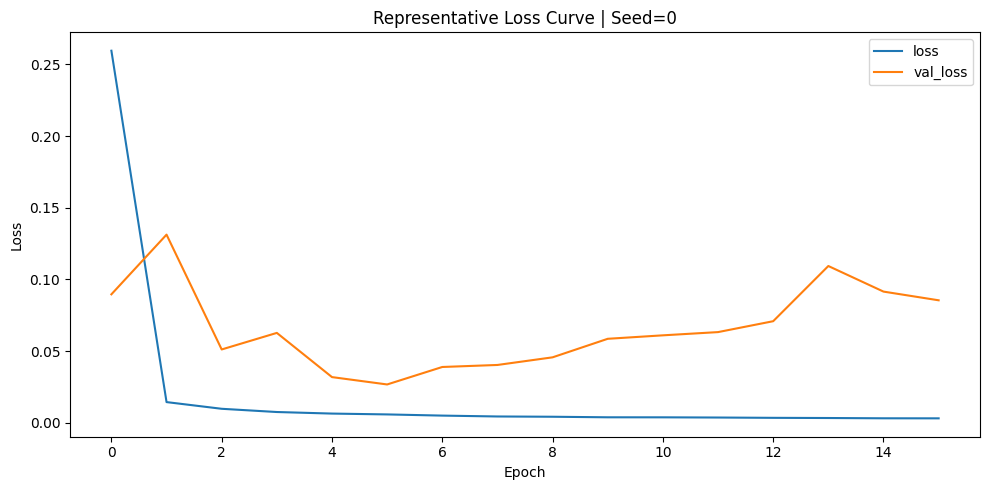

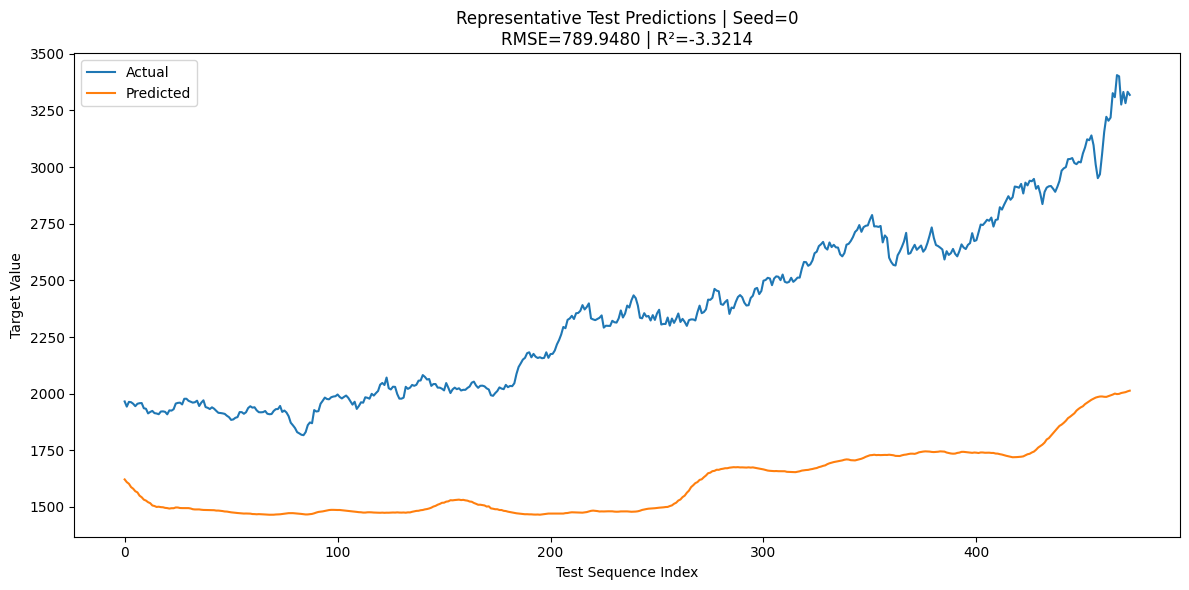

In [ ]:
if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Choose the MIX dataset variant.
        architecture_key="song_2025_2cnn_1bilstm",  # Choose the Zhang-style architecture as the initial baseline.
        pbounds_key="tamene_2025",  # Choose one study-inspired hyperparameter space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=5,  # Keep the example search small enough to be practical.
        bayes_n_iter=10,  # Keep the example search small enough to be practical.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )


##Trail 3

|   iter    |  target   | lookback  |  filters  | kernel... | lstm_u... | dropou... | learni... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -42496.00 | 24.988962 | 244.96000 | 7.3919636 | 139.79877 | 0.1624074 | 0.0016443 | 4.1742508 |
| 2         | -44670.38 | 36.788227 | 166.64976 | 7.2484354 | 53.087674 | 0.4879639 | 0.0083411 | 4.6370173 |
| 3         | -56983.82 | 20.363799 | 73.082610 | 4.8254534 | 128.71346 | 0.2727780 | 0.0029831 | 5.8355586 |
| 4         | -51157.29 | 19.347852 | 97.440401 | 5.1981710 | 118.41049 | 0.4140703 | 0.0020767 | 5.5427033 |
| 5         | -51818.60 | 30.217949 | 42.404892 | 6.6452691 | 75.578618 | 0.1260206 | 0.0094939 | 6.8968960 |
| 6         | -55986.81 | 35.401536 | 100.23348 | 3.5860326 | 152.63495 | 0.2760609 | 0.0013081 | 5.4855307 |
| 7         | -60742.61 | 16.825324 | 235.68777 | 4.5526798 | 149.37834 | 0.2246844 | 0.0052486 | 5.6401308 |
| 8       

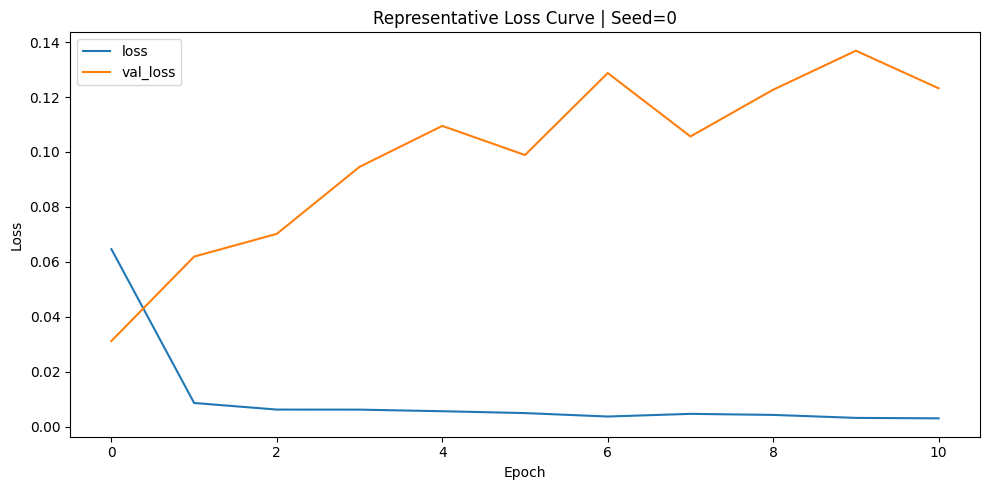

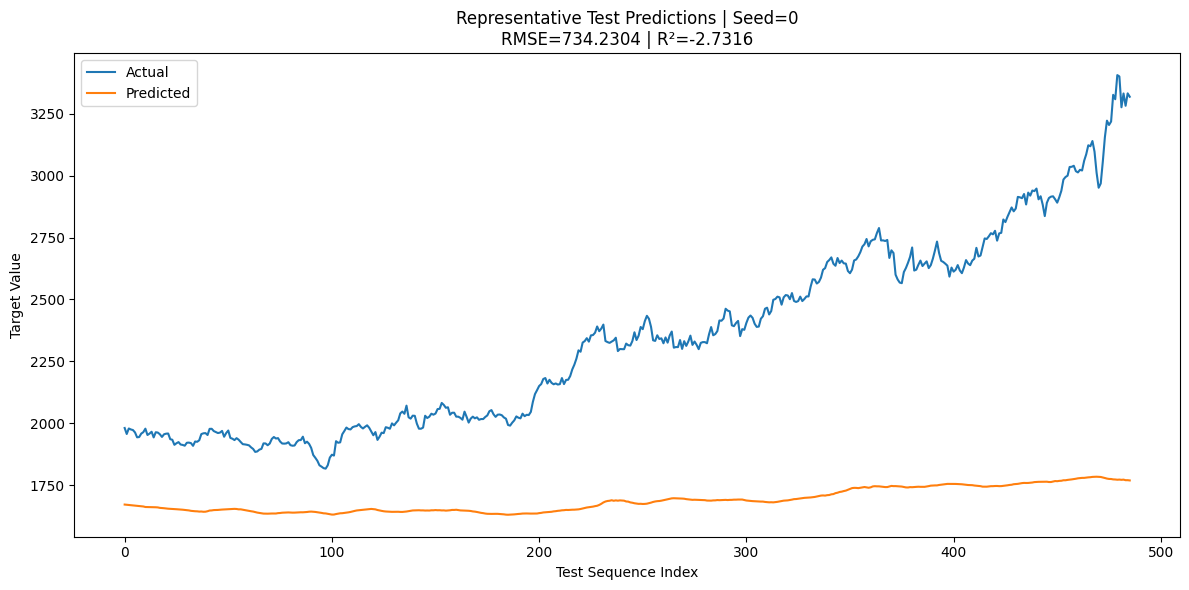

In [ ]:
if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Choose the MIX dataset variant.
        architecture_key="song_2025_2cnn_2bilstm",  # Choose the Zhang-style architecture as the initial baseline.
        pbounds_key="tamene_2025",  # Choose one study-inspired hyperparameter space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=15,  # Keep the example search small enough to be practical.
        bayes_n_iter=40,  # Keep the example search small enough to be practical.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )


##Trail 4

|   iter    |  target   | lookback  |  filters  | kernel... | lstm_u... | dropou... | learni... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -146.6150 | 24.988962 | 244.96000 | 7.3919636 | 139.79877 | 0.1624074 | 0.0016443 | 4.1742508 |
| 2         | -259.2857 | 36.788227 | 166.64976 | 7.2484354 | 53.087674 | 0.4879639 | 0.0083411 | 4.6370173 |
| 3         | -154.4168 | 20.363799 | 73.082610 | 4.8254534 | 128.71346 | 0.2727780 | 0.0029831 | 5.8355586 |
| 4         | -163.9558 | 19.347852 | 97.440401 | 5.1981710 | 118.41049 | 0.4140703 | 0.0020767 | 5.5427033 |
| 5         | -156.2054 | 30.217949 | 42.404892 | 6.6452691 | 75.578618 | 0.1260206 | 0.0094939 | 6.8968960 |
| 6         | -151.6637 | 35.401536 | 100.23348 | 3.5860326 | 152.63495 | 0.2760609 | 0.0013081 | 5.4855307 |
| 7         | -169.8904 | 16.825324 | 235.68777 | 4.5526798 | 149.37834 | 0.2246844 | 0.0052486 | 5.6401308 |
| 8       

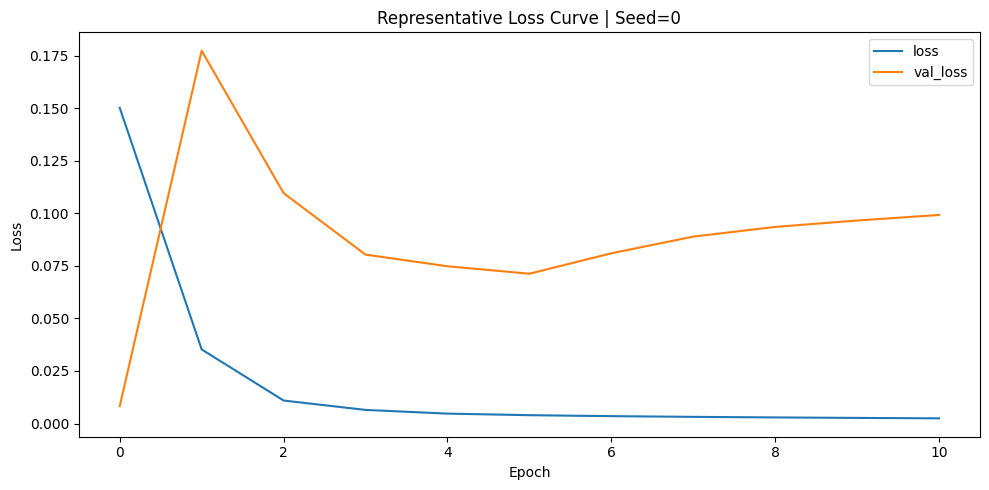

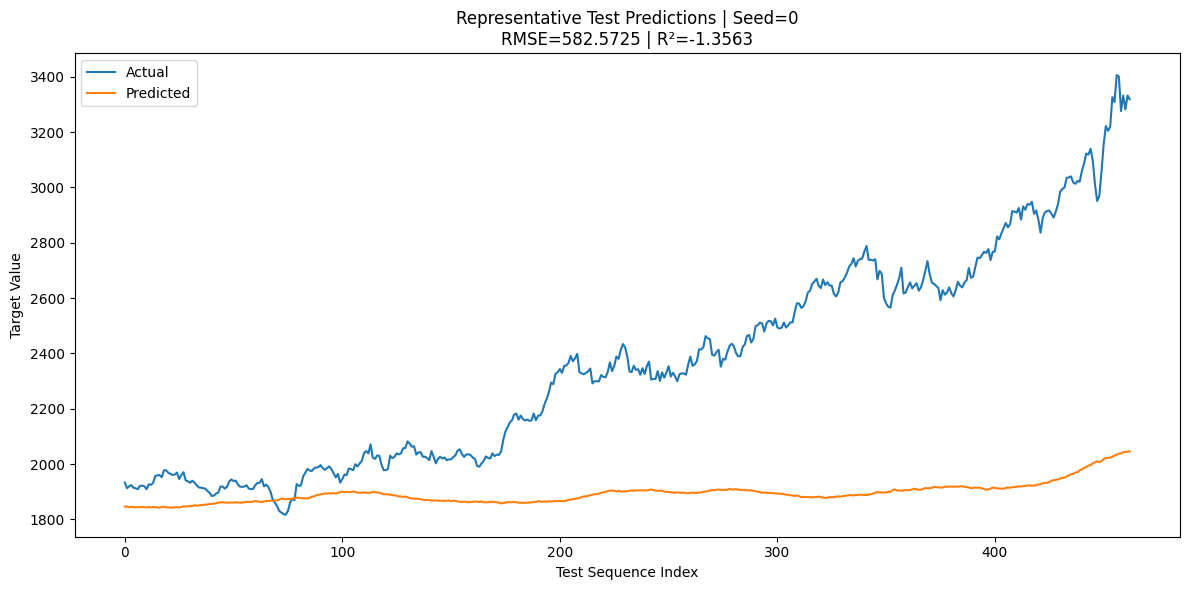

In [ ]:
if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Choose the MIX dataset variant.
        architecture_key="song_2025_bidirectional_deep",  # Choose the Zhang-style architecture as the initial baseline.
        pbounds_key="tamene_2025",  # Choose one study-inspired hyperparameter space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=10,  # Keep the example search small enough to be practical.
        bayes_n_iter=30,  # Keep the example search small enough to be practical.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )


##Trail 5

|   iter    |  target   | lookback  |  filters  | kernel... | lstm_u... | dropou... | learni... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -191.0159 | 24.988962 | 244.96000 | 7.3919636 | 139.79877 | 0.1624074 | 0.0016443 | 4.1742508 |
| 2         | -229.2330 | 36.788227 | 166.64976 | 7.2484354 | 53.087674 | 0.4879639 | 0.0083411 | 4.6370173 |
| 3         | -161.2410 | 20.363799 | 73.082610 | 4.8254534 | 128.71346 | 0.2727780 | 0.0029831 | 5.8355586 |
| 4         | -186.3211 | 19.347852 | 97.440401 | 5.1981710 | 118.41049 | 0.4140703 | 0.0020767 | 5.5427033 |
| 5         | -190.6941 | 30.217949 | 42.404892 | 6.6452691 | 75.578618 | 0.1260206 | 0.0094939 | 6.8968960 |
| 6         | -114.1067 | 20.139801 | 73.140637 | 5.2930612 | 129.56670 | 0.2158221 | 0.0026055 | 6.2461045 |
| 7         | -180.8688 | 20.050853 | 73.312254 | 4.9642285 | 130.22256 | 0.3142097 | 0.0023691 | 6.2571900 |
| 8       

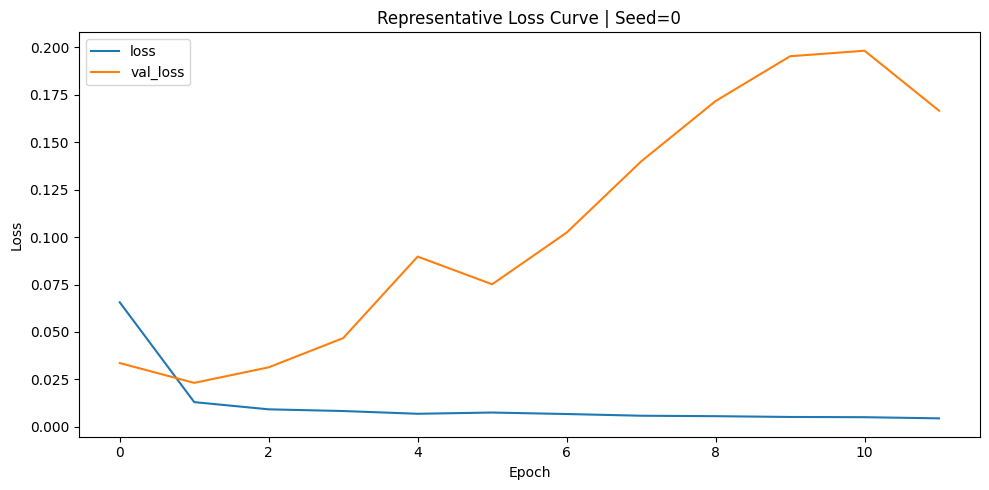

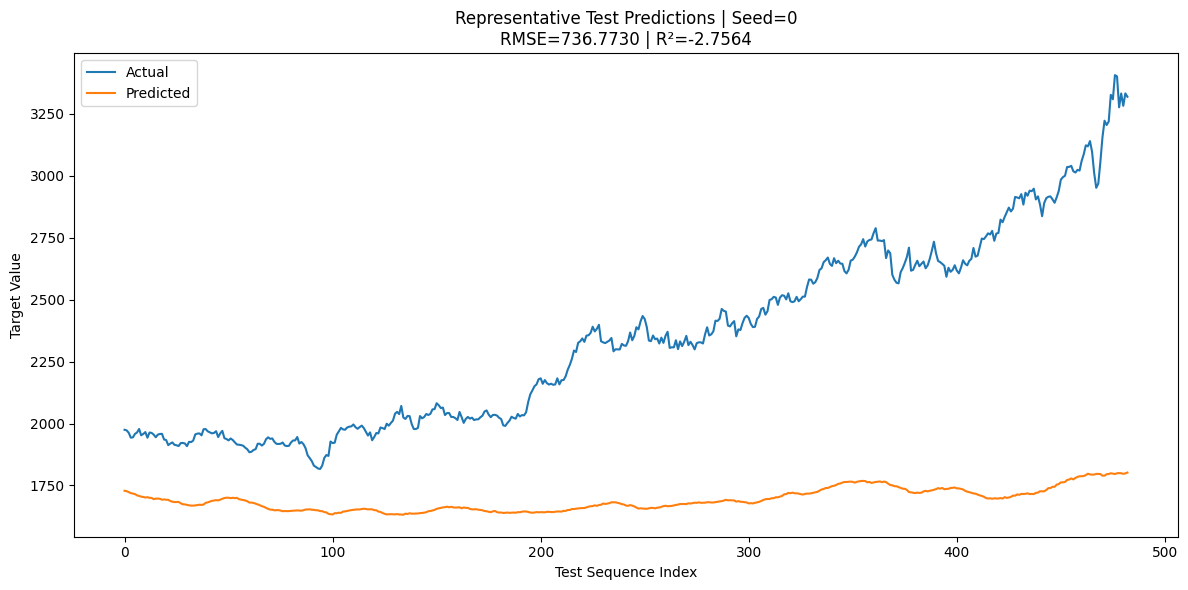

In [ ]:
if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Choose the MIX dataset variant.
        architecture_key="song_2025_1cnn_1bilstm",  # Choose the Zhang-style architecture as the initial baseline.
        pbounds_key="tamene_2025",  # Choose one study-inspired hyperparameter space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=5,  # Keep the example search small enough to be practical.
        bayes_n_iter=20,  # Keep the example search small enough to be practical.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )


##Trail 6

|   iter    |  target   | lookback  |  filters  | lstm_u... | kernel... | learni... | dropou... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -175.0178 | 32.479765 | 122.48000 | 102.27141 | 5.3946339 | 0.0016445 | 0.0156078 | 4.1161672 |
| 2         | -230.9465 | 54.111750 | 83.324881 | 99.974967 | 3.0823379 | 0.0097021 | 0.0832459 | 4.4246782 |
| 3         | -174.1214 | 24.000298 | 36.541305 | 61.207255 | 5.0990257 | 0.0043762 | 0.0291300 | 5.2237057 |
| 4         | -187.9477 | 22.137729 | 48.720200 | 67.170736 | 4.8242799 | 0.0078732 | 0.0199753 | 5.0284688 |
| 5         | -250.4324 | 42.066241 | 21.202446 | 90.324305 | 3.6820964 | 0.0007440 | 0.0948890 | 5.9312640 |
| 6         | -178.2209 | 24.363901 | 37.565554 | 60.684931 | 5.6651833 | 0.0040452 | 0.0507227 | 5.4363247 |
| 7         | -212.1165 | 16.0      | 22.105361 | 59.276113 | 3.0       | 0.01      | 1e-05     | 4.0       |
| 8       

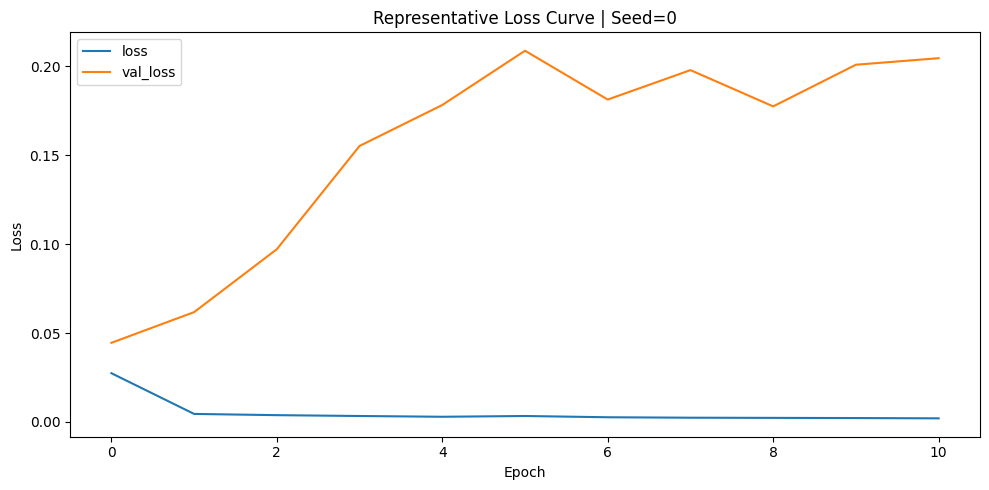

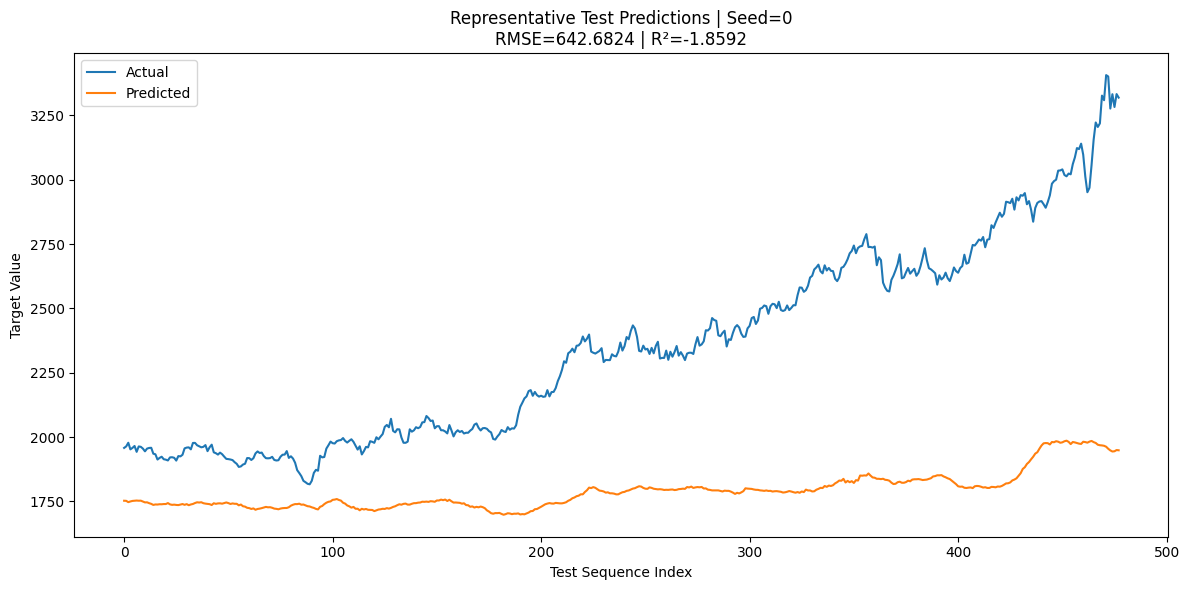

In [ ]:
if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Choose the MIX dataset variant.
        architecture_key="song_2025_1cnn_1bilstm",  # Choose the Zhang-style architecture as the initial baseline.
        pbounds_key="song_2025_wide",  # Choose one study-inspired hyperparameter space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=5,  # Keep the example search small enough to be practical.
        bayes_n_iter=20,  # Keep the example search small enough to be practical.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )


##Trial 7

In [ ]:
if __name__ == "__main__":  # Run an example experiment only when the script is executed directly.
    example_config = ExperimentConfig(  # Define one concrete experiment setup.
        dataset_key="RRL",  # Use the RRL dataset variant.
        architecture_key="model_1cnn_2bilstm",  # Use the balanced 1CNN + 2BiLSTM architecture.
        pbounds_key="PBOUNDS_RECOMMENDED",  # Use the tighter recommended hyperparameter search space.
        use_denoising=False,  # Start with the raw-data branch.
        bayes_init_points=10,  # Use a more reliable initial Bayesian search budget.
        bayes_n_iter=30,  # Use a stronger optimization run for better parameter search.
    )
    artifacts = run_full_experiment(example_config)  # Execute the finalized pipeline.
    print("\nBest Parameters:\n", artifacts["best_params"])  # Print the selected hyperparameters.
    print("\nPer-Seed Results:\n", artifacts["per_seed_results"])  # Print the per-seed final-test results.
    print("\nSummary (Mean ± Std):\n", artifacts["summary"])  # Print the summary table.
    plot_loss_history(  # Plot one representative training-vs-validation loss curve.
        artifacts["representative_history"],  # Use the first representative seed history.
        title=f"Representative Loss Curve | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )
    plot_predicted_vs_actual(  # Plot predicted-vs-actual values on the untouched test set.
        artifacts["representative_predictions"]["y_true"],  # Actual test values.
        artifacts["representative_predictions"]["y_pred"],  # Predicted test values.
        title=f"Representative Test Predictions | Seed={artifacts['representative_seed']}",  # Provide a descriptive title.
    )

|   iter    |  target   | lookback  |  filters  | kernel... | lstm_u... | dropou... | learni... | batch_... |
-------------------------------------------------------------------------------------------------------------
| 1         | -158.4113 | 22.487123 | 92.057144 | 4.1959818 | 67.103410 | 0.1390046 | 0.0005523 | 4.1161672 |
| 2         | -195.7364 | 36.252932 | 64.089200 | 4.1242177 | 25.482083 | 0.3424774 | 0.0025140 | 4.4246782 |
| 3         | -159.4623 | 17.091099 | 30.672360 | 2.9127267 | 61.782463 | 0.2079862 | 0.0009445 | 5.2237057 |
| 4         | -171.7378 | 15.905828 | 39.371571 | 3.0990855 | 56.837038 | 0.2962939 | 0.0006790 | 5.0284688 |
| 5         | -156.1617 | 28.587607 | 19.716033 | 3.8226345 | 36.277736 | 0.1162628 | 0.0028517 | 5.9312640 |
| 6         | -139.5864 | 34.635125 | 40.369101 | 2.2930163 | 73.264777 | 0.2100381 | 0.0004539 | 4.9903538 |
| 7         | -148.2214 | 12.962878 | 88.745632 | 2.7763399 | 71.701604 | 0.1779277 | 0.0016081 | 5.0934205 |
| 8       